WITHIN-PARTICIPANT RSA, two different versions

In [1]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend


In [2]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"


In [3]:
whichVersion = '3sec' #persentence, 3sec, 6sec

In [4]:
# ------------------------
# Load 
# ------------------------

whichROI = "hippocampus" # hippocampus

whichStory = "tunnel"  # tunnel, 21styear, shapessocial, shapesphysical, prettymouthaffair,prettymouthparanoia

base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

# make sure foundation scores for pretty mouth are found
if whichStory == 'prettymouthaffair':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichStory == 'prettymouthparanoia':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
else:
    print('use foundation scores of WhichStory')
    if whichVersion =='persentence':
        foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
        foundationScores = pd.read_excel(foundationScores_file)
    elif whichVersion =='3sec':
        foundationScores_file = f"{foundationScores_dir}{whichStory}_3_seconds_MFT_MAC.xlsx"
        foundationScores = pd.read_excel(foundationScores_file)
    elif whichVersion =='6sec':
        foundationScores_file = f"{foundationScores_dir}{whichStory}_6_seconds_MFT_MAC.xlsx"
        foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"

left = np.load(data_dir + f"{whichStory}_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_{whichROI}_R_3D_clean.npy")



use foundation scores of WhichStory
21styear
TPJ_refined_mask


In [5]:
# List columns
virtue_cols = [
    "MAC_a_fairness_virtue", "MAC_a_group_virtue", "MAC_a_deference_virtue",
    "MAC_a_heroism_virtue", "MAC_a_reciprocity_virtue",
    "MAC_a_family_virtue", "MAC_a_property_virtue"
]

vice_cols = [
    "MAC_a_fairness_vice", "MAC_a_group_vice", "MAC_a_deference_vice",
    "MAC_a_heroism_vice", "MAC_a_reciprocity_vice",
    "MAC_a_family_vice", "MAC_a_property_vice"
]

all_cols = virtue_cols + vice_cols

# 1. --- NON-MORAL: all 14 columns are zero ---
nonmoral_df = foundationScores[foundationScores[all_cols].sum(axis=1) == 0]

# Filter out nonmoral rows to classify the rest
moral_df = foundationScores[foundationScores[all_cols].sum(axis=1) != 0].copy()

# Find the column with the highest value per row
moral_df["max_col"] = moral_df[all_cols].idxmax(axis=1)

# 2. --- VICE: max column is a vice column ---
vice_df = moral_df[moral_df["max_col"].isin(vice_cols)].drop(columns=["max_col"])

# 3. --- VIRTUE: max column is a virtue column ---
virtue_df = moral_df[moral_df["max_col"].isin(virtue_cols)].drop(columns=["max_col"])

# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec
nonmoral_df = nonmoral_df[["start","end"]]
nonmoral_df = nonmoral_df.copy()

vice_df = vice_df[["start","end"]]
vice_df = vice_df.copy()

virtue_df = virtue_df[["start","end"]]
virtue_df = virtue_df.copy()

# go from seconds to TRs for start and end column
nonmoral_df["startTR"] = nonmoral_df["start"] / 1.5
nonmoral_df["endTR"] = nonmoral_df["end"] / 1.5

vice_df["startTR"] = vice_df["start"] / 1.5
vice_df["endTR"] = vice_df["end"] / 1.5

virtue_df["startTR"] = virtue_df["start"] / 1.5
virtue_df["endTR"] = virtue_df["end"] / 1.5

# round to full TRs/volumes
nonmoral_df["startTR"] = nonmoral_df["startTR"].round(0).astype(int)
nonmoral_df["endTR"] = nonmoral_df["endTR"].round(0).astype(int)

vice_df["startTR"] = vice_df["startTR"].round(0).astype(int)
vice_df["endTR"] = vice_df["endTR"].round(0).astype(int)

virtue_df["startTR"] = virtue_df["startTR"].round(0).astype(int)
virtue_df["endTR"] = virtue_df["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
nonmoral_df['startTR'] = nonmoral_df['startTR'] + 3
nonmoral_df['endTR'] = nonmoral_df['endTR'] + 3

vice_df['startTR'] = vice_df['startTR'] + 3
vice_df['endTR'] = vice_df['endTR'] + 3

virtue_df['startTR'] = virtue_df['startTR'] + 3
virtue_df['endTR'] = virtue_df['endTR'] + 3


## split in odd vs even events (so, separate events and compute mean pattern across TRs within an event to use)

Running RSA for vice sentences...
Running RSA for virtue sentences...
Running RSA for non-moral sentences...
Paired t-test vice - virtue: t = 2.841, p = 0.0090
Paired t-test vice to baseline: t = nan, p = nan
Paired t-test virtue to baseline: t = nan, p = nan
Mean RSA vice: 0.29553656590426525 Mean RSA virtue: 0.24515605505605506 Mean RSA non-moral: nan


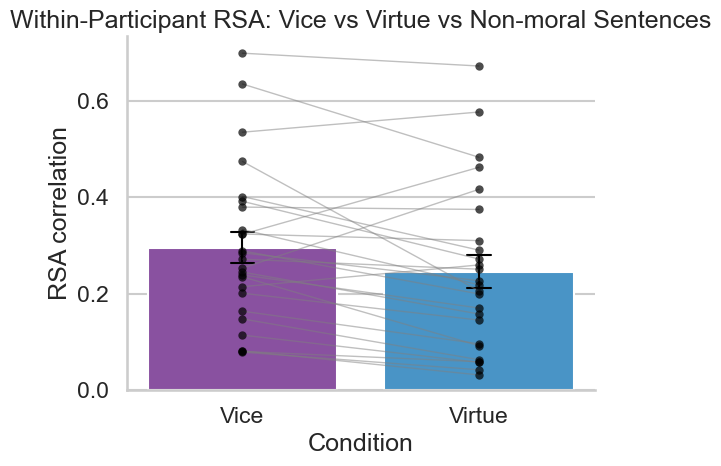

In [6]:
# ================================================================
def run_within_participant_rsa(data_array, events):
    """
    data_array : np.ndarray, shape (voxels x volumes x participants)
    events     : DataFrame with columns ['startTR', 'endTR']
    Returns    : np.array of RSA correlations per participant
    """
    # Sort and clean events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    event_ids = events.index.values

    # Odd/even split to minimize temporal autocorrelation
    split1_ids = event_ids[::2]
    split2_ids = event_ids[1::2]

    # Equalize length
    n_events = min(len(split1_ids), len(split2_ids))
    split1_ids = split1_ids[:n_events]
    split2_ids = split2_ids[:n_events]

    n_participants = data_array.shape[2]
    results = []

    for p in range(n_participants):
        data = data_array[:, :, p].copy()
        data = zscore(data, axis=1, ddof=1)  # normalize voxelwise over time

        split1_patterns, split2_patterns = [], []

        for eid in split1_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split1_patterns.append(pattern)

        for eid in split2_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split2_patterns.append(pattern)

        split1_patterns = np.column_stack(split1_patterns)
        split2_patterns = np.column_stack(split2_patterns)

        # Compute representational dissimilarity matrices (1 - Pearson correlation)
        rdm1 = squareform(pdist(split1_patterns.T, metric='correlation'))
        rdm2 = squareform(pdist(split2_patterns.T, metric='correlation'))

        # Vectorize upper triangles and correlate (Spearman)
        iu = np.triu_indices(n_events, k=1)
        rsa_corr, _ = spearmanr(rdm1[iu], rdm2[iu])
        results.append(rsa_corr)

    return np.array(results)


# ================================================================
# Run RSA separately for moral and non-moral events
# ================================================================
print("Running RSA for vice sentences...")
rsa_vice_left  = run_within_participant_rsa(left,  vice_df)
rsa_vice_right = run_within_participant_rsa(right, vice_df)

print("Running RSA for virtue sentences...")
rsa_virtue_left  = run_within_participant_rsa(left,  virtue_df)
rsa_virtue_right = run_within_participant_rsa(right, virtue_df)

print("Running RSA for non-moral sentences...")
rsa_nonmoral_left  = run_within_participant_rsa(left,  nonmoral_df)
rsa_nonmoral_right = run_within_participant_rsa(right, nonmoral_df)

# ================================================================
# Average across hemispheres and compute difference
# ================================================================
rsa_vice_mean    = (rsa_vice_left + rsa_vice_right) / 2
rsa_virtue_mean    = (rsa_virtue_left + rsa_virtue_right) / 2
rsa_nonmoral_mean = (rsa_nonmoral_left + rsa_nonmoral_right) / 2

# ================================================================
# Combine into one DataFrame
# ================================================================
rsa_df = pd.DataFrame({
    'participant': np.arange(len(rsa_vice_mean)),
    'rsa_vice_left': rsa_vice_left,
    'rsa_vice_right': rsa_vice_right,
    'rsa_vice_mean': rsa_vice_mean,
    'rsa_virtue_left': rsa_virtue_left,
    'rsa_virtue_right': rsa_virtue_right,
    'rsa_virtue_mean': rsa_virtue_mean,
    'rsa_nonmoral_left': rsa_nonmoral_left,
    'rsa_nonmoral_right': rsa_nonmoral_right,
    'rsa_nonmoral_mean': rsa_nonmoral_mean,
})

# ================================================================
# === Group stats: paired t-test ===
# ================================================================
t_stat, p_val = ttest_rel(rsa_df['rsa_vice_mean'], rsa_df['rsa_virtue_mean'])
print("Paired t-test vice - virtue: t = {:.3f}, p = {:.4f}".format(t_stat, p_val))

t_stat2, p_val2 = ttest_rel(rsa_df['rsa_vice_mean'], rsa_df['rsa_nonmoral_mean'])
print("Paired t-test vice to baseline: t = {:.3f}, p = {:.4f}".format(t_stat2, p_val2))

t_stat3, p_val3 = ttest_rel(rsa_df['rsa_virtue_mean'], rsa_df['rsa_nonmoral_mean'])
print("Paired t-test virtue to baseline: t = {:.3f}, p = {:.4f}".format(t_stat3, p_val3))

print("Mean RSA vice:", rsa_df['rsa_vice_mean'].mean(), 
      "Mean RSA virtue:", rsa_df['rsa_virtue_mean'].mean(),
      "Mean RSA non-moral:", rsa_df['rsa_nonmoral_mean'].mean())

plt.figure(figsize=(6, 5))
sns.set(style='whitegrid', context='talk')

# ================================================================
# Prepare for plotting
# ================================================================
plot_df = pd.melt(
    rsa_df,
    id_vars=['participant'],
    value_vars=['rsa_vice_mean','rsa_virtue_mean', 'rsa_nonmoral_mean'],
    var_name='Condition',
    value_name='RSA'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'rsa_vice_mean': 'Vice',
    'rsa_virtue_mean': 'Virtue',
    'rsa_nonmoral_mean': 'Non-moral'
})

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='RSA', hue='Condition', legend=False,
    errorbar='se', capsize=0.1,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB', '#E67E22']
)

# Overlay participant dots + connecting lines
sns.stripplot(
    data=plot_df,
    x='Condition', y='RSA',
    color='black', size=6, jitter=False, alpha=0.7
)

# Connect participant dots
for pid in rsa_df['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'RSA'].values
    plt.plot([0, 1, 2], vals, color='gray', alpha=0.5, linewidth=1)

ax.set_title('Within-Participant RSA: Vice vs Virtue vs Non-moral Sentences')
ax.set_ylabel('RSA correlation')
sns.despine()
plt.tight_layout()
plt.show()

## split within event to have odd event split within event instead of across event

Running within-event split RSA for vice sentences...
Running within-event split RSA for virtue sentences...
Running within-event split RSA for non-moral sentences...
Paired t-test vice - virtue: t = 1.305, p = 0.2042
Paired t-test vice to baseline: t = nan, p = nan
Paired t-test virtue to baseline: t = nan, p = nan
Mean RSA vice: 0.7249078044768216 Mean RSA virtue: 0.7163907803571077 Mean RSA non-moral: nan


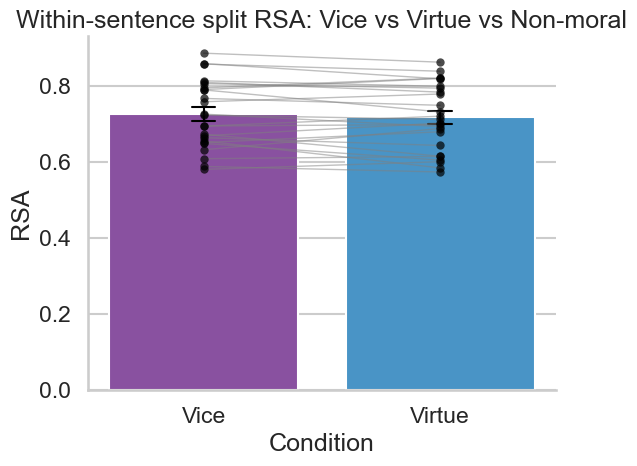

In [7]:

# === compute per-event split patterns (odd/even TRs within event) ===
def event_split_patterns_for_events(events):
    """
    Given events DataFrame with integer 'startTR' and 'endTR', produce
    for each event the indices of TRs for split A and split B (odd/even within event).
    Returns:
      valid_event_idx: list of event indices that have at least one TR in each split
      splitA_tr_indices: list of lists (TR indices for split A per valid event)
      splitB_tr_indices: list of lists (TR indices for split B per valid event)
    """
    valid_event_idx = []
    splitA_tr_indices = []
    splitB_tr_indices = []
    
    for i, ev in events.iterrows():
        s = int(ev['startTR'])
        e = int(ev['endTR'])
        # full list of TR indices for this event
        trs = np.arange(s, e + 1)
        if len(trs) == 0:
            continue
        # odd/even within the event (relative indexing)
        # choose trs with relative index %2 == 0 vs %2 == 1
        rel_idx = np.arange(len(trs))
        a_trs = trs[rel_idx % 2 == 0]
        b_trs = trs[rel_idx % 2 == 1]
        # require at least one TR in each split
        if len(a_trs) >= 1 and len(b_trs) >= 1:
            valid_event_idx.append(i)
            splitA_tr_indices.append(a_trs)
            splitB_tr_indices.append(b_trs)
    return valid_event_idx, splitA_tr_indices, splitB_tr_indices

# === RSA function using within-event split ===
def run_within_event_rsa(data_array, events):
    """
    data_array : np.ndarray with shape (voxels, n_volumes, n_participants)
    events     : DataFrame with 'startTR' and 'endTR' (integers)
    Returns    : np.array of RSA correlations per participant (hemisphere)
    """
    # Clean & ensure integer TRs
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR']   = events['endTR'].astype(int)
    
    # Build split TR lists per event, dropping events that don't have at least one TR in both splits
    valid_event_idx, splitA_trs_list, splitB_trs_list = event_split_patterns_for_events(events)
    n_events = len(valid_event_idx)
    if n_events < 2:
        raise ValueError("Not enough valid events after within-event splitting.")
    
    n_participants = data_array.shape[2]
    rsa_results = np.full(n_participants, np.nan)
    
    for p in range(n_participants):
        # voxel x time
        data = data_array[:, :, p].copy()
        # normalize voxel timecourses to be comparable (zscore across time per voxel)
        data = zscore(data, axis=1, ddof=1)
        
        # build per-event pattern estimates for split A and split B
        patternsA = []
        patternsB = []
        for a_trs, b_trs in zip(splitA_trs_list, splitB_trs_list):
            # mean over the specified TRs (axis=1 collapsed)
            patA = np.mean(data[:, a_trs], axis=1)
            patB = np.mean(data[:, b_trs], axis=1)
            patternsA.append(patA)
            patternsB.append(patB)
        
        # stack to voxels x events
        patternsA = np.column_stack(patternsA)  # voxels x n_events
        patternsB = np.column_stack(patternsB)
        
        # compute RDMs
        rdmA = squareform(pdist(patternsA.T, metric='correlation'))
        rdmB = squareform(pdist(patternsB.T, metric='correlation'))
        
        # vectorize upper triangle
        iu = np.triu_indices(n_events, k=1)
        vecA = rdmA[iu]
        vecB = rdmB[iu]
        
        # Spearman between RDMs: assesses rank-order consistency across pairwise relations
        rho, _ = spearmanr(vecA, vecB)
        rsa_results[p] = rho
    
    return rsa_results

# === Run for moral and non-moral, both hemispheres ===
print("Running within-event split RSA for vice sentences...")
rsa_virtue_left  = run_within_event_rsa(left,  virtue_df)
rsa_virtue_right = run_within_event_rsa(right, virtue_df)

print("Running within-event split RSA for virtue sentences...")
rsa_vice_left  = run_within_event_rsa(left,  vice_df)
rsa_vice_right = run_within_event_rsa(right, vice_df)

print("Running within-event split RSA for non-moral sentences...")
rsa_nonmoral_left  = run_within_event_rsa(left,  nonmoral_df)
rsa_nonmoral_right = run_within_event_rsa(right, nonmoral_df)

# average hemispheres
rsa_vice_mean    = (rsa_vice_left + rsa_vice_right) / 2
rsa_virtue_mean    = (rsa_virtue_left + rsa_virtue_right) / 2
rsa_nonmoral_mean = (rsa_nonmoral_left + rsa_nonmoral_right) / 2

# assemble dataframe
rsa_df = pd.DataFrame({
    'participant': np.arange(len(rsa_vice_mean)),
    'rsa_vice_left': rsa_vice_left,
    'rsa_vice_right': rsa_vice_right,
    'rsa_vice_mean': rsa_vice_mean,
    'rsa_virtue_left': rsa_virtue_left,
    'rsa_virtue_right': rsa_virtue_right,
    'rsa_virtue_mean': rsa_virtue_mean,
    'rsa_nonmoral_left': rsa_nonmoral_left,
    'rsa_nonmoral_right': rsa_nonmoral_right,
    'rsa_nonmoral_mean': rsa_nonmoral_mean,
})



# ================================================================
# === Group stats: paired t-test ===
# ================================================================
t_stat, p_val = ttest_rel(rsa_df['rsa_vice_mean'], rsa_df['rsa_virtue_mean'])
print("Paired t-test vice - virtue: t = {:.3f}, p = {:.4f}".format(t_stat, p_val))

t_stat2, p_val2 = ttest_rel(rsa_df['rsa_vice_mean'], rsa_df['rsa_nonmoral_mean'])
print("Paired t-test vice to baseline: t = {:.3f}, p = {:.4f}".format(t_stat2, p_val2))

t_stat3, p_val3 = ttest_rel(rsa_df['rsa_virtue_mean'], rsa_df['rsa_nonmoral_mean'])
print("Paired t-test virtue to baseline: t = {:.3f}, p = {:.4f}".format(t_stat3, p_val3))

print("Mean RSA vice:", rsa_df['rsa_vice_mean'].mean(), 
      "Mean RSA virtue:", rsa_df['rsa_virtue_mean'].mean(),
      "Mean RSA non-moral:", rsa_df['rsa_nonmoral_mean'].mean())


plt.figure(figsize=(6, 5))
sns.set(style='whitegrid', context='talk')

# ================================================================
# Prepare for plotting
# ================================================================
plot_df = pd.melt(
    rsa_df,
    id_vars=['participant'],
    value_vars=['rsa_vice_mean','rsa_virtue_mean', 'rsa_nonmoral_mean'],
    var_name='Condition',
    value_name='RSA'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'rsa_vice_mean': 'Vice',
    'rsa_virtue_mean': 'Virtue',
    'rsa_nonmoral_mean': 'Non-moral'
})

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='RSA', hue='Condition', legend=False,
    errorbar='se', capsize=0.1,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB', '#E67E22']
)

# Overlay participant dots + connecting lines
sns.stripplot(
    data=plot_df,
    x='Condition', y='RSA',
    color='black', size=6, jitter=False, alpha=0.7
)

# Connect participant dots
for pid in rsa_df['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'RSA'].values
    plt.plot([0, 1, 2], vals, color='gray', alpha=0.5, linewidth=1)


ax.set_title('Within-sentence split RSA: Vice vs Virtue vs Non-moral')
ax.set_ylabel('RSA')
sns.despine()
plt.tight_layout()
plt.show()


In [8]:
nonmoral_df.shape

(2, 4)

In [9]:
vice_df.shape

(68, 4)

In [10]:
virtue_df.shape

(55, 4)